# Earthformer — Wave Prediction (in=12h, out=4h)
Trained on 2020-01-01 to 2023-12-30 | Static mask from GEBCO depth

In [ ]:
import torch

cuda_available = torch.cuda.is_available()
print(f"Is CUDA available? {cuda_available}")
if cuda_available:
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
print(f"PyTorch CUDA Version: {torch.version.cuda}")

## MASTER CONFIGURATION

In [2]:
# =============================================================================
# MASTER CONFIGURATION CELL
# =============================================================================
import torch
import os

version = "v4_earthformer"

# --- Core Parameters ---
LOOKBACK_HOURS    = 12   # Input sequence length (T_in)
FORECAST_HORIZON_HOURS = 14    # Output sequence length (T_out)
# NOTE: No sliding window, no error correction — direct 4-step forecast

# --- File Paths (unchanged from v3) ---
RAW_DATA_PATH    = r'/home/aidl/Wave-Prediction/dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
STATIC_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_GEBCO_resampled1.nc'

BASE_DIR           = r'/home/aidl/babe_prediction'
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, f'processed_data_lookback_{LOOKBACK_HOURS}_earthformer')
MODEL_SAVE_DIR     = '/home/aidl/Wave-Prediction/models/'
MODEL_SAVE_PATH    = os.path.join(MODEL_SAVE_DIR, f'{version}.pth')

# --- Feature Engineering (unchanged from v3) ---
VARS_TO_USE = ['VCMX', 'VHM0_SW1', 'VSDmag', 'VHM0_WW', 'VTM01_WW', 'VTM02', 'VTM01_SW1', 'VTM10']
TARGET_VARS = ['VCMX']
NUM_OUTPUT_CHANNELS = 1       # 1
INPUT_CHANNELS      = len(VARS_TO_USE) + 2   # 10  (8 time-varying + depth + mask)

# --- Training Hyperparameters ---
LEARNING_RATE          = 1e-4
BATCH_SIZE             = 4
EPOCHS                 = 50
EARLY_STOPPING_PATIENCE = 5

# --- System ---
NUM_WORKERS = 4

# --- Earthformer Hyper-parameters ---
# dim must be divisible by num_heads
EF_DIM        = 64    # hidden channel dim after input projection
EF_DEPTH      = 2     # number of cuboid attention blocks
EF_NUM_HEADS  = 4     # attention heads
EF_CUBOID_T   = 4     # temporal cuboid size  (≤ LOOKBACK_HOURS)
EF_CUBOID_H   = 8     # spatial cuboid height (tile size)
EF_CUBOID_W   = 9     # spatial cuboid width  (tile size)
EF_DROPOUT    = 0.1

print("--- Configuration Summary ---")
print(f"Version           : {version}")
print(f"Input  (T_in)     : {LOOKBACK_HOURS} hours")
print(f"Output (T_out)    : {FORECAST_HORIZON_HOURS} hours")
print(f"Input Channels    : {INPUT_CHANNELS}  ({len(VARS_TO_USE)} time-varying + 2 static)")
print(f"Output Channels   : {NUM_OUTPUT_CHANNELS}  ({', '.join(TARGET_VARS)})")
print(f"Processed Data    : {PROCESSED_DATA_DIR}")
print(f"Model Save Dir    : {MODEL_SAVE_DIR}")
print("-----------------------------")

--- Configuration Summary ---
Version           : v4_earthformer
Input  (T_in)     : 12 hours
Output (T_out)    : 14 hours
Input Channels    : 10  (8 time-varying + 2 static)
Output Channels   : 1  (VCMX)
Processed Data    : /home/aidl/babe_prediction/processed_data_lookback_12_earthformer
Model Save Dir    : /home/aidl/Wave-Prediction/models/
-----------------------------


## STEP 1 — Pre-processing  
Same data splits as v3. Only `total_window_size` changes to 12+4=16.

In [3]:
# =============================================================================
# STEP 1: PRE-PROCESSING  (same logic as v3, window size is now 12+4=16)
# =============================================================================
import os
import pickle
import xarray as xr
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm
import warnings
import shutil

warnings.filterwarnings('ignore')

if os.path.exists(PROCESSED_DATA_DIR):
    print(f"Removing old processed data: {PROCESSED_DATA_DIR}")
    shutil.rmtree(PROCESSED_DATA_DIR)

print("\n--- Starting Pre-processing ---")

# Step 1: Load & clean
print("\n[1/5] Loading and cleaning data...")
ds_raw = xr.open_dataset(RAW_DATA_PATH)
ds_raw['VSDmag'] = np.sqrt(ds_raw['VSDX']**2 + ds_raw['VSDY']**2)
ds_clean = ds_raw[VARS_TO_USE].astype(np.float32).fillna(0)
print("✅ Time-varying data loaded.")

ds_static   = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask  = ds_static['mask'].values.astype(np.float32)
print("✅ Static data loaded.")

# Step 2: Same splits as v3
print("\n[2/5] Splitting data...")
ds_train = ds_clean.sel(time=slice('2020-01-01', '2022-12-31'))
ds_val   = ds_clean.sel(time=slice('2023-01-01', '2023-06-30'))
ds_test  = ds_clean.sel(time=slice('2023-07-01', '2023-12-30'))
ds_splits = {'train': ds_train, 'val': ds_val, 'test': ds_test}
print(f"  Train : {len(ds_train.time)} steps")
print(f"  Val   : {len(ds_val.time)} steps")
print(f"  Test  : {len(ds_test.time)} steps")

# Step 3: Fit scalers on train only
print("\n[3/5] Fitting scalers on TRAINING data...")
scalers = {}
for var in tqdm(VARS_TO_USE, desc="Fitting scalers"):
    scaler = MinMaxScaler()
    scaler.fit(ds_train[var].values.reshape(-1, 1))
    scalers[var] = scaler

depth_scaler = MinMaxScaler()
depth_scaler.fit(ocean_depth.reshape(-1, 1))
scalers['ocean_depth'] = depth_scaler

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scalers, f)
print(f"✅ Scalers saved to {scaler_path}")

# Step 4: Scale static features
print("\n[4/5] Scaling static features...")
scaled_depth     = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch  = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch    = np.expand_dims(ocean_mask,  axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)  # (2, H, W)
print("✅ Static features scaled.")

# Step 5: Generate samples  — window = 12 + 4 = 16
print("\n[5/5] Generating samples (window=16: 12 in + 4 out)...")
total_window_size = LOOKBACK_HOURS + FORECAST_HORIZON_HOURS  # 16

for split_name, ds_split in ds_splits.items():
    split_dir = os.path.join(PROCESSED_DATA_DIR, split_name)
    os.makedirs(split_dir, exist_ok=True)

    T = len(ds_split.time)
    n_samples = T - total_window_size + 1
    print(f"  '{split_name}': {T} steps → {n_samples} samples")

    for i in tqdm(range(n_samples), desc=f"  {split_name}"):
        window = ds_split.isel(time=slice(i, i + total_window_size))

        # Scale time-varying variables
        tv_frames = []
        for var in VARS_TO_USE:
            d = window[var].values  # (T_win, H, W)
            d_scaled = scalers[var].transform(d.reshape(-1, 1)).reshape(d.shape)
            tv_frames.append(d_scaled)
        tv_np = np.stack(tv_frames, axis=1)  # (T_win, 8, H, W)

        # Tile static features across time
        static_tiled = np.tile(static_features_np[np.newaxis], (total_window_size, 1, 1, 1))  # (T_win,2,H,W)
        full_np = np.concatenate([tv_np, static_tiled], axis=1)  # (T_win, 10, H, W)

        # Split into X (first 12) and Y (last 4, time-varying only)
        X = torch.from_numpy(full_np[:LOOKBACK_HOURS].astype(np.float32))     # (12, 10, H, W)
        vcmx_idx = VARS_TO_USE.index('VCMX')
        Y = torch.from_numpy(tv_np[LOOKBACK_HOURS:, vcmx_idx:vcmx_idx+1].astype(np.float32))  # (14, 1, H, W)

        save_path = os.path.join(split_dir, f'sample_{i:06d}.pt')
        torch.save((X, Y), save_path)

print("\n✅ Pre-processing complete!")


--- Starting Pre-processing ---

[1/5] Loading and cleaning data...
✅ Time-varying data loaded.
✅ Static data loaded.

[2/5] Splitting data...
  Train : 26304 steps
  Val   : 4344 steps
  Test  : 4392 steps

[3/5] Fitting scalers on TRAINING data...


Fitting scalers:   0%|          | 0/8 [00:00<?, ?it/s]

✅ Scalers saved to /home/aidl/babe_prediction/processed_data_lookback_12_earthformer/scalers_mask.pkl

[4/5] Scaling static features...
✅ Static features scaled.

[5/5] Generating samples (window=16: 12 in + 4 out)...
  'train': 26304 steps → 26279 samples


  train:   0%|          | 0/26279 [00:00<?, ?it/s]

  'val': 4344 steps → 4319 samples


  val:   0%|          | 0/4319 [00:00<?, ?it/s]

  'test': 4392 steps → 4367 samples


  test:   0%|          | 0/4367 [00:00<?, ?it/s]


✅ Pre-processing complete!


## STEP 2 — Earthformer Model + Training

In [3]:
# =============================================================================
# STEP 2.1 — DataModule  (unchanged from v3)
# =============================================================================
import pytorch_lightning as pl
import os, glob
import torch
from torch.utils.data import Dataset, DataLoader

class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

class WaveDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size, num_workers):
        super().__init__()
        self.data_dir    = data_dir
        self.batch_size  = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            self.train_dataset = PreprocessedWaveDataset(os.path.join(self.data_dir, 'train'))
            self.val_dataset   = PreprocessedWaveDataset(os.path.join(self.data_dir, 'val'))
            print(f"DataModule: {len(self.train_dataset)} train / {len(self.val_dataset)} val samples")

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True,
                          num_workers=self.num_workers, pin_memory=True, persistent_workers=False)
    def val_dataloader(self):
        return DataLoader(self.val_dataset,   batch_size=self.batch_size, shuffle=False,
                          num_workers=self.num_workers, pin_memory=True, persistent_workers=False)

print("✅ DataModule defined.")

✅ DataModule defined.


In [4]:
# =============================================================================
# STEP 2.2 — Earthformer Model (from-scratch, pure PyTorch)
#
# Architecture:
#   Input  : (B, T_in=12,  C_in=10,  H, W)  ← 12 hours, 10 channels
#   Output : (B, T_out=4,  C_out=8,  H, W)  ← 4 hours,   8 variables
#
#   1. InputProj  : Conv2d per frame → embed each (C_in,H,W) → (dim,H,W)
#   2. PosEmbed   : learnable 3-D (T,H,W) position bias
#   3. Encoder    : N × CuboidAttentionBlock (partition space-time into cuboids)
#   4. Decoder    : learned query tokens (T_out frames) + cross-attn to encoder
#   5. OutputProj : Conv2d per frame → (C_out,H,W)
# =============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import math


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def pad_to_multiple(x, multiple, dim):
    """Pad tensor along `dim` so its size is divisible by `multiple`."""
    size = x.shape[dim]
    pad  = (multiple - size % multiple) % multiple
    if pad == 0:
        return x, 0
    pad_cfg = [0] * (2 * x.ndim)
    pad_cfg[-(2 * dim + 1)] = pad
    return F.pad(x, pad_cfg[::-1]), pad


# ---------------------------------------------------------------------------
# CuboidAttention  (the core Earthformer building block)
# ---------------------------------------------------------------------------
class CuboidSelfAttention(nn.Module):
    """
    Decomposes the (T,H,W) tensor into non-overlapping cuboids of size
    (ct, ch, cw) and applies multi-head self-attention within each cuboid
    in parallel.  Global vectors (one per cuboid) are concatenated to
    every local token to provide long-range context.
    """
    def __init__(self, dim, num_heads, cuboid_size=(4, 8, 8), dropout=0.0):
        super().__init__()
        self.dim         = dim
        self.num_heads   = num_heads
        self.head_dim    = dim // num_heads
        self.ct, self.ch, self.cw = cuboid_size
        self.scale       = self.head_dim ** -0.5

        self.qkv    = nn.Linear(dim, 3 * dim, bias=False)
        self.proj   = nn.Linear(dim, dim)
        self.drop   = nn.Dropout(dropout)

        # Global summary vector per cuboid (learnable, dim-dimensional)
        self.global_proj = nn.Linear(dim, dim)

    def forward(self, x):
        """
        x : (B, T, H, W, dim)
        """
        B, T, H, W, C = x.shape
        ct, ch, cw = self.ct, self.ch, self.cw

        # --- pad so T,H,W are divisible by cuboid sizes
        x_r = x.permute(0, 4, 1, 2, 3)           # (B,C,T,H,W)
        x_r, pt = pad_to_multiple(x_r, ct, dim=2)
        x_r, ph = pad_to_multiple(x_r, ch, dim=3)
        x_r, pw = pad_to_multiple(x_r, cw, dim=4)
        Tp, Hp, Wp = x_r.shape[2], x_r.shape[3], x_r.shape[4]
        x_r = x_r.permute(0, 2, 3, 4, 1)          # (B,Tp,Hp,Wp,C)

        nT, nH, nW = Tp // ct, Hp // ch, Wp // cw  # number of cuboids
        n_cuboids  = nT * nH * nW
        L          = ct * ch * cw                   # tokens per cuboid

        # --- reshape into cuboids
        x_c = x_r.view(B, nT, ct, nH, ch, nW, cw, C)
        x_c = x_c.permute(0, 1, 3, 5, 2, 4, 6, 7).contiguous()  # (B,nT,nH,nW,ct,ch,cw,C)
        x_c = x_c.view(B * n_cuboids, L, C)         # (B*n_cuboids, L, C)

        # --- global summary token (mean-pool each cuboid)
        g = x_c.mean(dim=1, keepdim=True)            # (B*n_cuboids, 1, C)
        g = self.global_proj(g)
        x_c = torch.cat([x_c, g], dim=1)             # (B*n_cuboids, L+1, C)

        # --- multi-head self-attention inside each cuboid
        qkv = self.qkv(x_c).reshape(B * n_cuboids, L + 1, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)                     # each (B*n_cub, heads, L+1, head_dim)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)

        out = (attn @ v)                             # (B*n_cub, heads, L+1, head_dim)
        out = out.transpose(1, 2).reshape(B * n_cuboids, L + 1, C)
        out = self.proj(out)

        # --- drop global token, restore spatial layout
        out = out[:, :L, :]                          # (B*n_cuboids, L, C)
        out = out.view(B, nT, nH, nW, ct, ch, cw, C)
        out = out.permute(0, 1, 4, 2, 5, 3, 6, 7).contiguous()  # (B,nT,ct,nH,ch,nW,cw,C)
        out = out.view(B, Tp, Hp, Wp, C)

        # --- remove padding
        if pt > 0: out = out[:, :T,  :,  :, :]
        if ph > 0: out = out[:,  :, :H,  :, :]
        if pw > 0: out = out[:,  :,  :, :W, :]

        return out   # (B, T, H, W, C)


# ---------------------------------------------------------------------------
# CuboidAttentionBlock  = LN + CuboidAttn + FFN  (pre-norm)
# ---------------------------------------------------------------------------
class CuboidAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads, cuboid_size=(4, 8, 8), mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = CuboidSelfAttention(dim, num_heads, cuboid_size, dropout)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (B, T, H, W, dim)
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


# ---------------------------------------------------------------------------
# Cross-Attention decoder block
# ---------------------------------------------------------------------------
class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.0):
        super().__init__()
        self.norm_q  = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.attn    = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2   = nn.LayerNorm(dim)
        self.ffn     = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim),
        )

    def forward(self, q, kv):
        # q, kv: (B, N, dim)
        q2, _ = self.attn(self.norm_q(q), self.norm_kv(kv), self.norm_kv(kv))
        q = q + q2
        q = q + self.ffn(self.norm2(q))
        return q


# ---------------------------------------------------------------------------
# Full Earthformer Network
# ---------------------------------------------------------------------------
class EarthformerNet(nn.Module):
    """
    Input  : (B, T_in,  C_in,  H, W)
    Output : (B, T_out, C_out, H, W)
    """
    def __init__(
        self,
        t_in,
        t_out,
        c_in,
        c_out,
        dim          = 64,
        depth        = 4,
        num_heads    = 4,
        cuboid_size  = (4, 8, 8),
        dropout      = 0.1,
    ):
        super().__init__()
        self.t_in  = t_in
        self.t_out = t_out
        self.dim   = dim

        # --- Input projection: project each (C_in, H, W) frame into dim channels
        self.input_proj = nn.Conv2d(c_in, dim, kernel_size=3, padding=1)

        # --- Learnable 3-D position embedding (T, H_max, W_max)
        # We use a fixed large size and slice at runtime
        self.pos_embed = nn.Parameter(torch.zeros(1, t_in, 1, 1, dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # --- Encoder: stack of cuboid attention blocks
        self.encoder = nn.ModuleList([
            CuboidAttentionBlock(dim, num_heads, cuboid_size, dropout=dropout)
            for _ in range(depth)
        ])
        self.enc_norm = nn.LayerNorm(dim)

        # --- Decoder queries: T_out learnable query frames, each (H,W,dim)
        # We broadcast over H and W at runtime; store as (t_out, dim)
        self.dec_queries = nn.Parameter(torch.zeros(1, t_out, dim))
        nn.init.trunc_normal_(self.dec_queries, std=0.02)

        # --- Decoder: cross-attention over flattened encoder memory
        self.decoder = nn.ModuleList([
            CrossAttentionBlock(dim, num_heads, dropout=dropout)
            for _ in range(depth // 2)
        ])
        self.dec_norm = nn.LayerNorm(dim)

        # --- Output projection: map dim → c_out per spatial position
        self.output_proj = nn.Conv2d(dim, c_out, kernel_size=3, padding=1)

    def forward(self, x):
        """
        x : (B, T_in, C_in, H, W)
        returns: (B, T_out, C_out, H, W)
        """
        B, T, C, H, W = x.shape

        # --- Input projection (apply Conv2d frame-by-frame)
        x_flat = x.view(B * T, C, H, W)
        z_flat = self.input_proj(x_flat)         # (B*T, dim, H, W)
        z = z_flat.view(B, T, self.dim, H, W)
        z = z.permute(0, 1, 3, 4, 2)             # (B, T, H, W, dim)

        # --- Add position embedding (broadcast over H, W)
        z = z + self.pos_embed[:, :T]             # (B, T, H, W, dim)

        # --- Encoder
        for blk in self.encoder:
            z = blk(z)                            # (B, T, H, W, dim)
        z = self.enc_norm(z)

        # --- Flatten encoder output for cross-attention key/value
        mem = z.reshape(B, T * H * W, self.dim)  # (B, T*H*W, dim)

        # --- Decoder queries: expand to (B, T_out, dim)
        q = self.dec_queries.expand(B, -1, -1)   # (B, T_out, dim)
        for blk in self.decoder:
            q = blk(q, mem)                       # (B, T_out, dim)
        q = self.dec_norm(q)                      # (B, T_out, dim)

        # --- Broadcast decoder output to spatial grid and project to c_out
        # q: (B, T_out, dim) → expand to (B, T_out, H, W, dim)
        q_spatial = q.unsqueeze(2).unsqueeze(3).expand(B, self.t_out, H, W, self.dim)
        q_flat    = q_spatial.reshape(B * self.t_out, H, W, self.dim)
        q_flat    = q_flat.permute(0, 3, 1, 2)   # (B*T_out, dim, H, W)
        out_flat  = self.output_proj(q_flat)       # (B*T_out, c_out, H, W)
        out       = out_flat.view(B, self.t_out, -1, H, W)  # (B, T_out, c_out, H, W)

        return out


# ---------------------------------------------------------------------------
# LightningModule
# ---------------------------------------------------------------------------
class WavePredLightningModule(pl.LightningModule):
    def __init__(self, t_in, t_out, c_in, c_out,
                 dim, depth, num_heads, cuboid_size, dropout, lr):
        super().__init__()
        self.save_hyperparameters()
        self.model = EarthformerNet(
            t_in=t_in, t_out=t_out, c_in=c_in, c_out=c_out,
            dim=dim, depth=depth, num_heads=num_heads,
            cuboid_size=cuboid_size, dropout=dropout
        )
        self.loss_fn = nn.MSELoss()
        self.history = {'train_loss': [], 'val_loss': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch   # x:(B,12,10,H,W)  y:(B,4,8,H,W)
        pred = self(x)
        loss = self.loss_fn(pred, y)
        self.log('train_loss', loss, on_step=True, on_epoch=True,
                 prog_bar=True, logger=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = self.loss_fn(pred, y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True,
                 logger=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        opt   = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.trainer.max_epochs)
        return [opt], [sched]

    def on_validation_epoch_end(self):
        if self.trainer.global_rank == 0:
            metrics = self.trainer.callback_metrics
            if 'val_loss' in metrics:
                v = metrics['val_loss']
                self.history['val_loss'].append(v.item() if isinstance(v, torch.Tensor) else float(v))
            if 'train_loss_epoch' in metrics:
                t = metrics['train_loss_epoch']
                self.history['train_loss'].append(t.item() if isinstance(t, torch.Tensor) else float(t))


# Quick sanity check
_m = EarthformerNet(
    t_in=LOOKBACK_HOURS, t_out=FORECAST_HORIZON_HOURS,
    c_in=INPUT_CHANNELS,  c_out=NUM_OUTPUT_CHANNELS,
    dim=EF_DIM, depth=EF_DEPTH, num_heads=EF_NUM_HEADS,
    cuboid_size=(EF_CUBOID_T, EF_CUBOID_H, EF_CUBOID_W), dropout=EF_DROPOUT
)
_x = torch.randn(2, LOOKBACK_HOURS, INPUT_CHANNELS, 72, 90)
_y = _m(_x)
print(f"✅ Earthformer sanity check passed!")
print(f"   Input  shape : {_x.shape}")
print(f"   Output shape : {_y.shape}   (expected B=2, T_out=14, C=1, H=72, W=90)")
total_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"   Trainable params: {total_params:,}")
del _m, _x, _y

✅ Earthformer sanity check passed!
   Input  shape : torch.Size([2, 12, 10, 72, 90])
   Output shape : torch.Size([2, 14, 1, 72, 90])   (expected B=2, T_out=14, C=1, H=72, W=90)
   Trainable params: 166,337


#1492m 9.6s

In [12]:
# =============================================================================
# STEP 2.3 — Configure and Run Training
# =============================================================================
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, TQDMProgressBar
import torch
import pytorch_lightning as pl

print("--- Starting Earthformer Training (Multi-GPU DDP Notebook) ---\n")

# DataModule
data_module = WaveDataModule(
    data_dir=PROCESSED_DATA_DIR,
    batch_size=1,
    num_workers=4
)

# LightningModule
lightning_model = WavePredLightningModule(
    t_in       = LOOKBACK_HOURS,
    t_out      = FORECAST_HORIZON_HOURS,
    c_in       = INPUT_CHANNELS,
    c_out      = NUM_OUTPUT_CHANNELS,
    dim        = EF_DIM,
    depth      = EF_DEPTH,
    num_heads  = EF_NUM_HEADS,
    cuboid_size= (EF_CUBOID_T, EF_CUBOID_H, EF_CUBOID_W),
    dropout    = EF_DROPOUT,
    lr         = LEARNING_RATE,
)

# Callbacks
checkpoint_callback = ModelCheckpoint(
    dirpath    = MODEL_SAVE_DIR,
    filename   = f'{version}-{{epoch:02d}}-{{val_loss:.4f}}',
    save_top_k = 1,
    monitor    = 'val_loss',
    mode       = 'min',
    verbose    = True,
)
early_stopping_callback = EarlyStopping(
    monitor   = 'val_loss',
    patience  = EARLY_STOPPING_PATIENCE,
    mode      = 'min',
    verbose   = True,
)
progress_bar_callback = TQDMProgressBar(refresh_rate=10)

# Trainer (same multi-GPU DDP notebook setup as v3)
trainer = pl.Trainer(
    accelerator          = 'gpu',
    devices              = [0],
    strategy             = 'auto',
    precision            = '16-mixed',
    accumulate_grad_batches = 4,
    max_epochs           = EPOCHS,
    callbacks            = [checkpoint_callback, early_stopping_callback, progress_bar_callback],
    log_every_n_steps    = 10,
    sync_batchnorm       = True,
    enable_progress_bar  = True,
)

print(f"Starting training for {EPOCHS} epochs on 2 GPUs ...\n")
trainer.fit(lightning_model, data_module)

print(f"\n✅ Training finished.")
print(f"   Best model: {checkpoint_callback.best_model_path}")
best_model_path = checkpoint_callback.best_model_path

--- Starting Earthformer Training (Multi-GPU DDP Notebook) ---



Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Starting training for 50 epochs on 2 GPUs ...

DataModule: 26279 train / 4319 val samples


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ EarthformerNet │  166 K │ train │     0 │
│ 1 │ loss_fn │ MSELoss        │      0 │ train │     0 │
└───┴─────────┴────────────────┴────────┴───────┴───────┘

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 19, global step 131400: 'val_loss' was not in top 1
/tmp/ipykernel_142480/1489344846.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(self.file_p

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 5 records. Best score: 0.014. Signaling Trainer to stop.
Epoch 20, global step 137970: 'val_loss' was not in top 1



✅ Training finished.
   Best model: /home/aidl/Wave-Prediction/models/v4_earthformer-epoch=15-val_loss=0.0137.ckpt


{'images': [], 'audio': [], 'histograms': [], 'scalars': ['hp_metric', 'train_loss_step', 'epoch', 'val_loss', 'train_loss_epoch'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}
Train Loss History: 21
Validation Loss History: 21
0.014991923235356808 0.013747544959187508


NameError: name 'version' is not defined

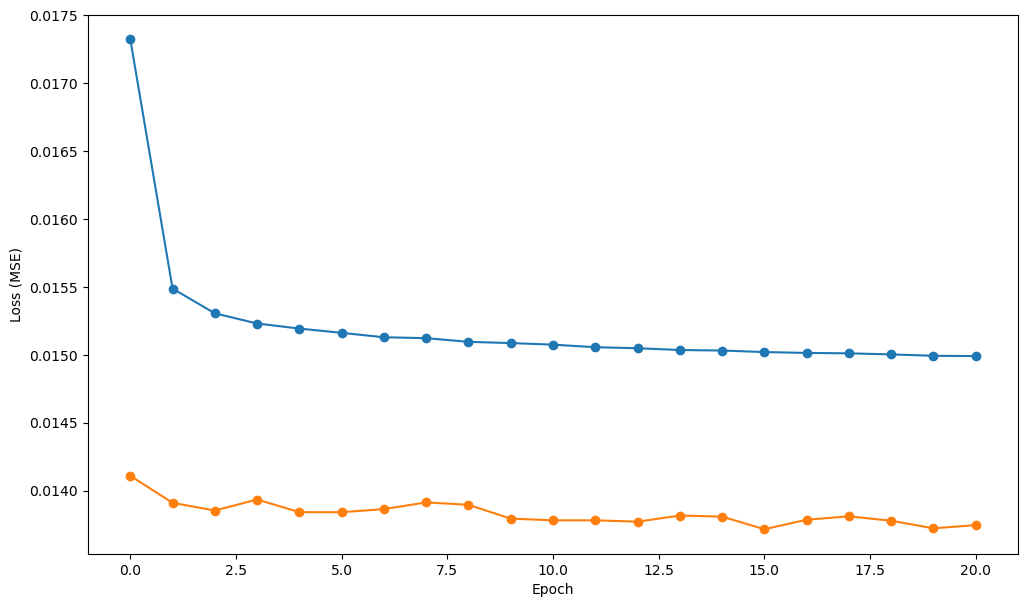

In [1]:
from tensorboard.backend.event_processing import event_accumulator
f1 = "/home/aidl/Wave-Prediction/"
f2 = "lightning_logs/version_23/events.out.tfevents.1777752954.aidl-X11DAi-N.142480.1"

event_file = f1+f2
ea = event_accumulator.EventAccumulator(event_file)
ea.Reload()

print(ea.Tags())  # see available metrics

train_events = ea.Scalars('train_loss_epoch')
val_events = ea.Scalars('val_loss')

train_loss = [x.value for x in train_events]
val_loss   = [x.value for x in val_events]

print("Train Loss History:", len(train_loss))
print("Validation Loss History:", len(val_loss))

full_history = {
    'train_loss': train_loss,
    'val_loss': val_loss
}
print(train_loss[-1], val_loss[-1])

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.plot(full_history['train_loss'], label='Training Loss', marker='o')
plt.plot(full_history['val_loss'], label='Validation Loss', marker='o')


plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title(f'{version}_Training & Validation Loss (Lookback: {LOOKBACK_HOURS}hrs)')
plt.legend()
plt.grid(True)
plt.xticks(range(len(full_history['train_loss']))) # Ensure integer ticks for epochs
plt.tight_layout()
plt.savefig(f'{version}_training_history_lookback_{LOOKBACK_HOURS}.png', dpi=300)
plt.show()

# print(f"✅ Training history plot saved to '{version}_training_history_lookback_{LOOKBACK_HOURS}.png'")

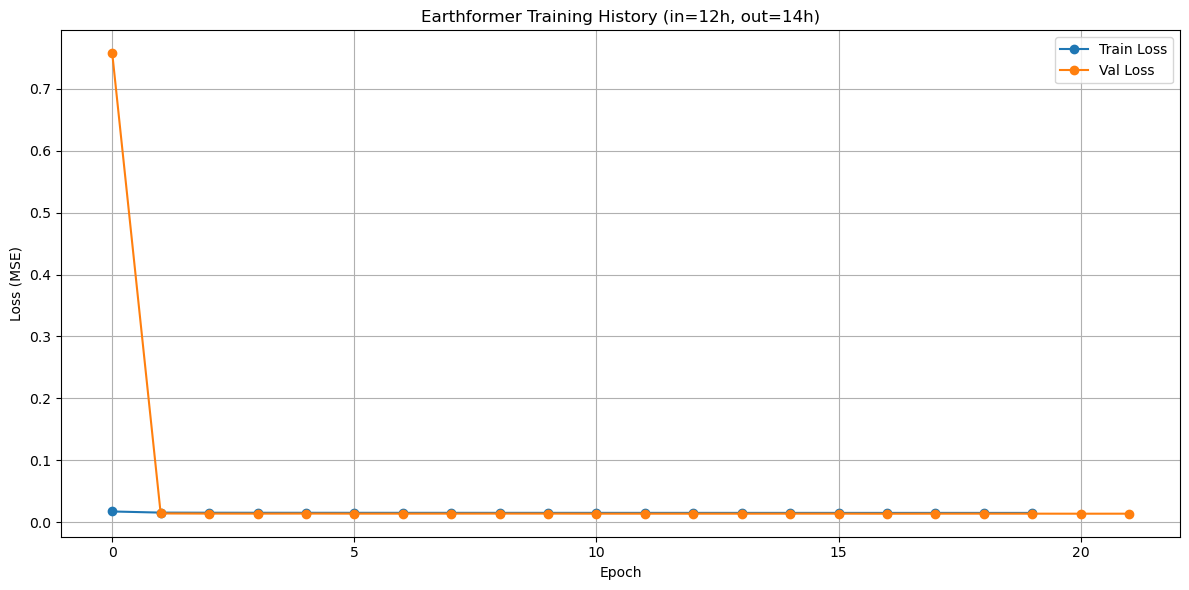

✅ Saved 'v4_earthformer_training_history.png'


In [13]:
# =============================================================================
# STEP 2.4 — Plot Training History
# =============================================================================
import matplotlib.pyplot as plt

history = lightning_model.history

plt.figure(figsize=(12, 6))
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'],   label='Val Loss',   marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title(f'Earthformer Training History (in={LOOKBACK_HOURS}h, out={FORECAST_HORIZON_HOURS}h)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{version}_training_history.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_training_history.png'")

## STEP 3 — Direct 4-Step Evaluation (no sliding window, no error correction)

In [5]:
best_model_path = "/home/aidl/Wave-Prediction/models/v4_earthformer-epoch=15-val_loss=0.0137.ckpt"

In [14]:
# =============================================================================
# STEP 3: DIRECT 4-HOUR FORECAST EVALUATION ON TEST SET
#
# We feed 12-hour inputs from the test set and predict 4 hours ahead.
# No sliding window.  No error correction.  Clean direct evaluation.
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os, pickle, glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Load scalers ---
scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
with open(scaler_path, 'rb') as f:
    scalers = pickle.load(f)
print("✅ Scalers loaded.")

# --- Load best checkpoint ---
print(f"Loading weights from: {best_model_path}")
checkpoint = torch.load(best_model_path, map_location=device)

eval_model = EarthformerNet(
    t_in=LOOKBACK_HOURS, t_out=FORECAST_HORIZON_HOURS,
    c_in=INPUT_CHANNELS,  c_out=NUM_OUTPUT_CHANNELS,
    dim=EF_DIM, depth=EF_DEPTH, num_heads=EF_NUM_HEADS,
    cuboid_size=(EF_CUBOID_T, EF_CUBOID_H, EF_CUBOID_W), dropout=0.0
)

# Strip 'model.' prefix added by Lightning
new_state_dict = OrderedDict()
for k, v in checkpoint['state_dict'].items():
    new_key = k[len('model.'):] if k.startswith('model.') else k
    new_state_dict[new_key] = v
eval_model.load_state_dict(new_state_dict)
eval_model.to(device)
eval_model.eval()
print("✅ Model loaded and in eval mode.")

# --- Build test DataLoader directly from saved .pt files ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx): return torch.load(self.file_paths[idx])

test_dataset = PreprocessedWaveDataset(os.path.join(PROCESSED_DATA_DIR, 'test'))
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f"Test set: {len(test_dataset)} samples → {len(test_loader)} batches")

# --- Run inference ---
all_preds   = []   # list of (B, 4, 8, H, W)  — scaled
all_targets = []   # list of (B, 4, 8, H, W)  — scaled

with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Evaluating'):
        x = x.to(device)           # (B, 12, 10, H, W)
        pred = eval_model(x)       # (B,  4,  8, H, W)  — scaled [0,1]
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y.numpy())

preds_scaled   = np.concatenate(all_preds,   axis=0)   # (N, 4, 8, H, W)
targets_scaled = np.concatenate(all_targets, axis=0)   # (N, 4, 8, H, W)

# --- Inverse-transform to original units ---
N, T_out, n_vars, H, W = preds_scaled.shape
preds_orig   = np.zeros_like(preds_scaled)
targets_orig = np.zeros_like(targets_scaled)

for vi, var in enumerate(TARGET_VARS):
    sc = scalers[var]
    preds_orig  [:, :, vi] = sc.inverse_transform(
        preds_scaled  [:, :, vi].reshape(-1, 1)).reshape(N, T_out, H, W)
    targets_orig[:, :, vi] = sc.inverse_transform(
        targets_scaled[:, :, vi].reshape(-1, 1)).reshape(N, T_out, H, W)

print(f"\n✅ Inference complete. Shape: {preds_orig.shape}  (N_samples, 4h, 8vars, H, W)")

# --- Overall metrics ---
overall_rmse = np.sqrt(np.mean((preds_orig - targets_orig)**2))
overall_mae  = np.mean(np.abs(preds_orig  - targets_orig))
print(f"\n📊 Overall Test Metrics (4-hour direct forecast):")
print(f"   RMSE : {overall_rmse:.4f}")
print(f"   MAE  : {overall_mae:.4f}")

# --- Per-step metrics ---
print(f"\n📊 Per-Forecast-Step RMSE / MAE:")
for t in range(T_out):
    r = np.sqrt(np.mean((preds_orig[:,t]-targets_orig[:,t])**2))
    m = np.mean(np.abs(preds_orig[:,t]-targets_orig[:,t]))
    print(f"   Hour +{t+1}: RMSE={r:.4f}  MAE={m:.4f}")

# --- Per-variable metrics ---
print(f"\n📊 Per-Variable Metrics (averaged over all 4 steps):")
for vi, var in enumerate(TARGET_VARS):
    r = np.sqrt(np.mean((preds_orig[:,:,vi]-targets_orig[:,:,vi])**2))
    m = np.mean(np.abs(preds_orig[:,:,vi]-targets_orig[:,:,vi]))
    print(f"   {var:12s}: RMSE={r:.4f}  MAE={m:.4f}")

Using device: cuda
✅ Scalers loaded.
Loading weights from: /home/aidl/Wave-Prediction/models/v4_earthformer-epoch=15-val_loss=0.0137.ckpt
✅ Model loaded and in eval mode.
Test set: 4367 samples → 1092 batches


Evaluating:   0%|          | 0/1092 [00:00<?, ?it/s]


✅ Inference complete. Shape: (4367, 14, 1, 72, 90)  (N_samples, 4h, 8vars, H, W)

📊 Overall Test Metrics (4-hour direct forecast):
   RMSE : 1.9684
   MAE  : 1.4477

📊 Per-Forecast-Step RMSE / MAE:
   Hour +1: RMSE=1.9405  MAE=1.4297
   Hour +2: RMSE=1.9407  MAE=1.4327
   Hour +3: RMSE=1.9417  MAE=1.4391
   Hour +4: RMSE=1.9436  MAE=1.4416
   Hour +5: RMSE=1.9467  MAE=1.4402
   Hour +6: RMSE=1.9506  MAE=1.4435
   Hour +7: RMSE=1.9560  MAE=1.4463
   Hour +8: RMSE=1.9629  MAE=1.4486
   Hour +9: RMSE=1.9709  MAE=1.4504
   Hour +10: RMSE=1.9798  MAE=1.4534
   Hour +11: RMSE=1.9896  MAE=1.4553
   Hour +12: RMSE=1.9998  MAE=1.4586
   Hour +13: RMSE=2.0108  MAE=1.4618
   Hour +14: RMSE=2.0221  MAE=1.4664

📊 Per-Variable Metrics (averaged over all 4 steps):
   VCMX        : RMSE=1.9684  MAE=1.4477


--- Plot 1: Error Evolution Over 4 Forecast Hours ---


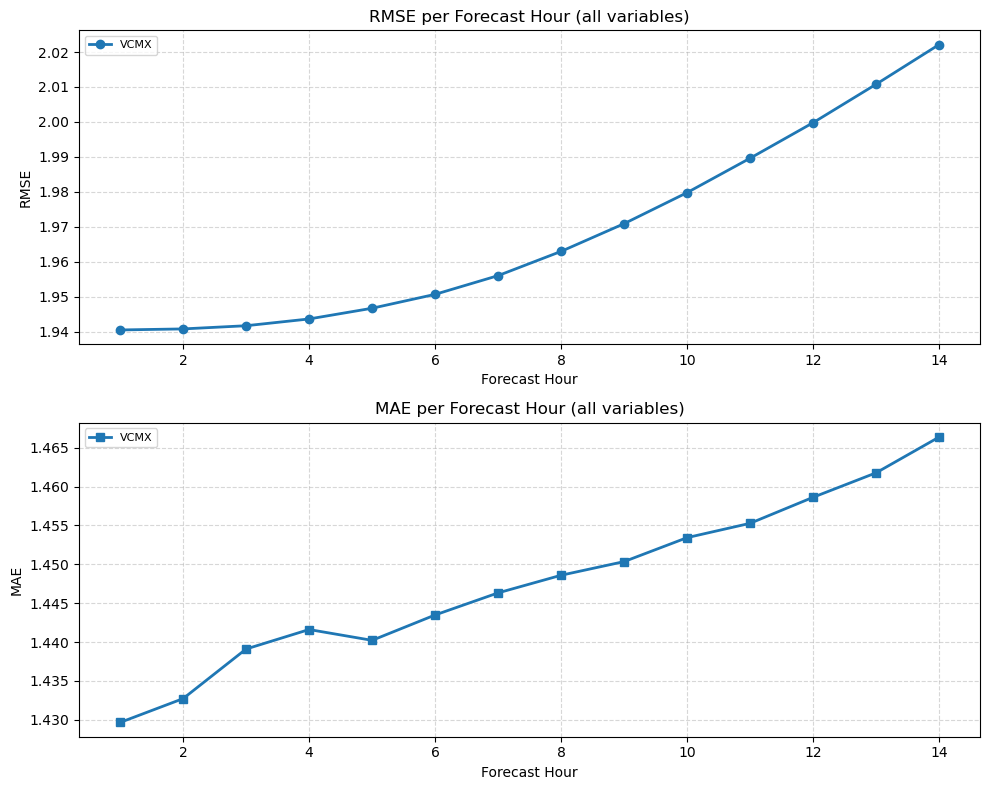

✅ Saved 'v4_earthformer_error_evolution.png'

--- Plot 2: Predictions vs Ground Truth (spatially averaged) ---


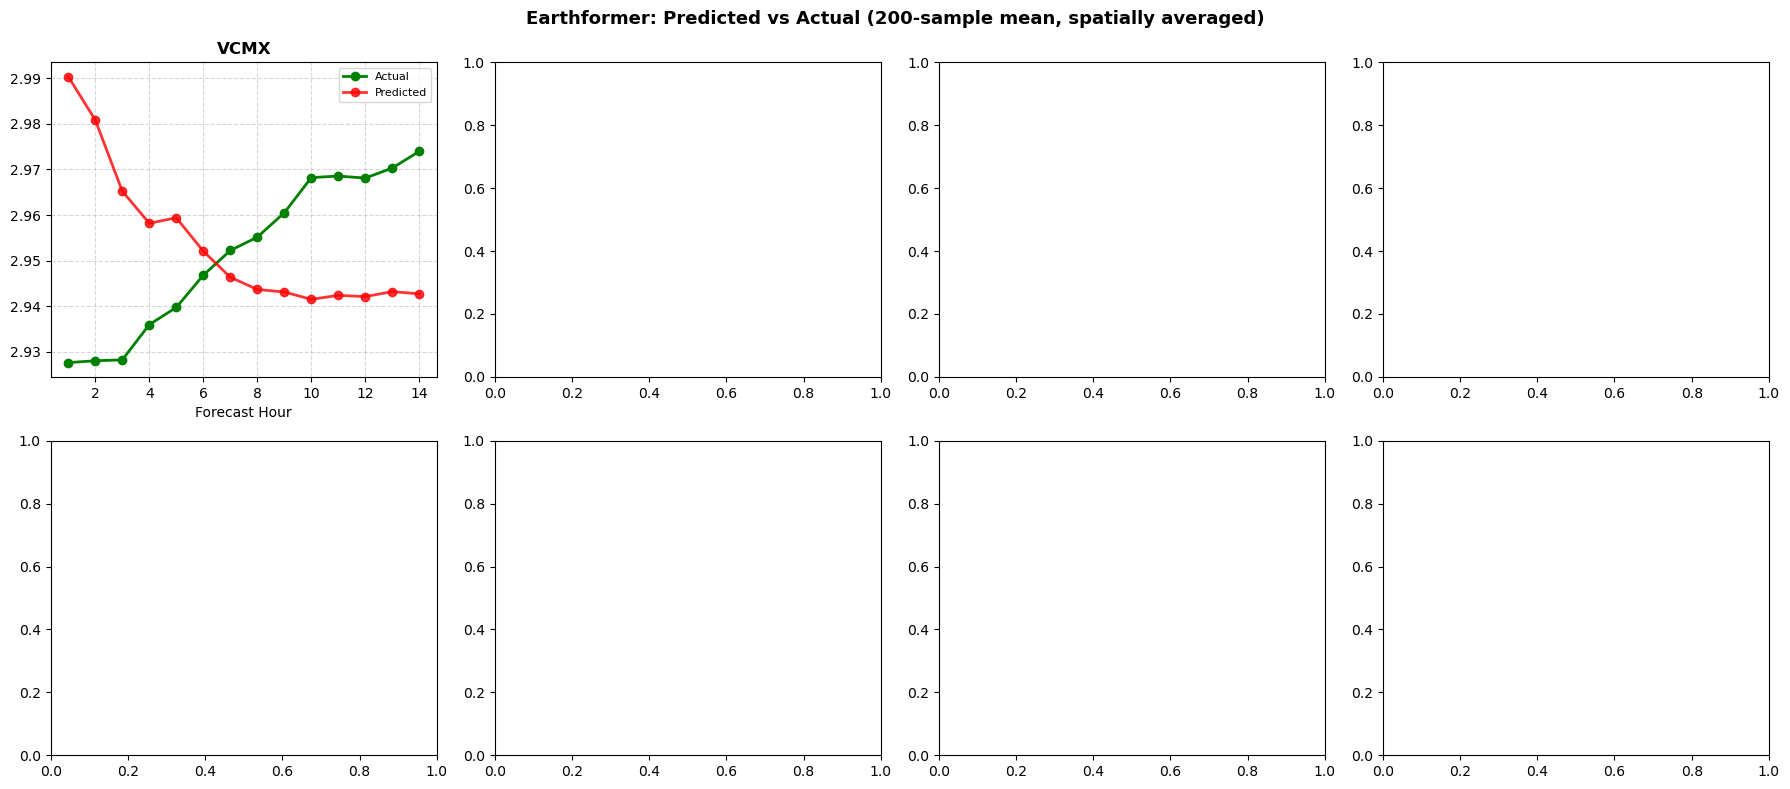

✅ Saved 'v4_earthformer_pred_vs_actual_all_vars.png'

--- Plot 3: Overall RMSE per Forecast Step ---


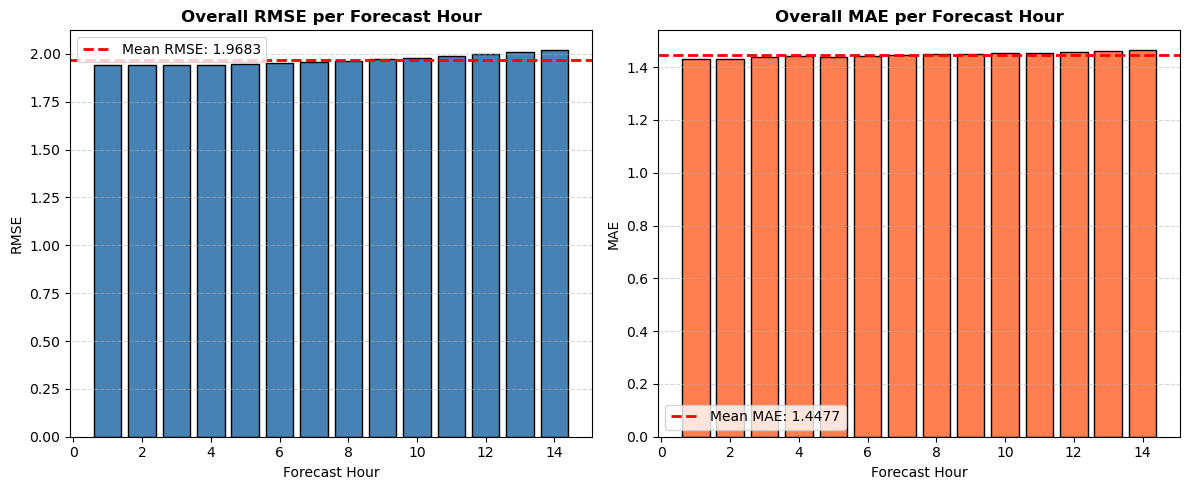

✅ Saved 'v4_earthformer_overall_hourly_metrics.png'


In [15]:
# =============================================================================
# STEP 3, PART 2 — Visualizations
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

hours = np.arange(1, FORECAST_HORIZON_HOURS + 1)

# --- Plot 1: Per-variable RMSE/MAE across the 4 forecast hours ---
print("--- Plot 1: Error Evolution Over 4 Forecast Hours ---")

hourly_rmse_per_var = {}
hourly_mae_per_var  = {}

for vi, var in enumerate(TARGET_VARS):
    p = preds_orig[:,  :, vi, :, :]   # (N, 4, H, W)
    t = targets_orig[:, :, vi, :, :]  # (N, 4, H, W)
    hourly_rmse_per_var[var] = np.sqrt(np.mean((p - t)**2, axis=(0, 2, 3)))  # (4,)
    hourly_mae_per_var[var]  = np.mean(np.abs(p - t),     axis=(0, 2, 3))   # (4,)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
for var in TARGET_VARS:
    axes[0].plot(hours, hourly_rmse_per_var[var], marker='o', label=var, linewidth=2)
    axes[1].plot(hours, hourly_mae_per_var[var],  marker='s', label=var, linewidth=2)
axes[0].set_title('RMSE per Forecast Hour (all variables)')
axes[0].set_xlabel('Forecast Hour')
axes[0].set_ylabel('RMSE')
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[1].set_title('MAE per Forecast Hour (all variables)')
axes[1].set_xlabel('Forecast Hour')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{version}_error_evolution.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_error_evolution.png'")

# --- Plot 2: Spatially-averaged predictions vs targets per step (all vars) ---
print("\n--- Plot 2: Predictions vs Ground Truth (spatially averaged) ---")
pred_smean   = preds_orig.mean(axis=(3, 4))     # (N, 4, 8)
target_smean = targets_orig.mean(axis=(3, 4))   # (N, 4, 8)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for vi, var in enumerate(TARGET_VARS):
    # Use a random subset of 200 samples for clarity
    idx = np.random.choice(len(pred_smean), min(200, len(pred_smean)), replace=False)
    p_h = pred_smean[idx, :, vi].mean(axis=0)    # (4,) mean over samples
    t_h = target_smean[idx, :, vi].mean(axis=0)  # (4,)
    axes[vi].plot(hours, t_h, 'g-o', label='Actual',    linewidth=2)
    axes[vi].plot(hours, p_h, 'r-o', label='Predicted', linewidth=2, alpha=0.8)
    axes[vi].set_title(var, fontweight='bold')
    axes[vi].set_xlabel('Forecast Hour')
    axes[vi].legend(fontsize=8)
    axes[vi].grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Earthformer: Predicted vs Actual (200-sample mean, spatially averaged)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{version}_pred_vs_actual_all_vars.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_pred_vs_actual_all_vars.png'")

# --- Plot 3: Overall RMSE per forecast step ---
print("\n--- Plot 3: Overall RMSE per Forecast Step ---")
overall_hourly_rmse = np.sqrt(np.mean((preds_orig - targets_orig)**2, axis=(0, 2, 3, 4)))  # (4,)
overall_hourly_mae  = np.mean(np.abs(preds_orig  - targets_orig),     axis=(0, 2, 3, 4))   # (4,)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(hours, overall_hourly_rmse, color='steelblue', edgecolor='black')
axes[0].axhline(overall_hourly_rmse.mean(), color='r', linestyle='--', lw=2,
                label=f'Mean RMSE: {overall_hourly_rmse.mean():.4f}')
axes[0].set_title('Overall RMSE per Forecast Hour', fontweight='bold')
axes[0].set_xlabel('Forecast Hour')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

axes[1].bar(hours, overall_hourly_mae, color='coral', edgecolor='black')
axes[1].axhline(overall_hourly_mae.mean(), color='r', linestyle='--', lw=2,
                label=f'Mean MAE: {overall_hourly_mae.mean():.4f}')
axes[1].set_title('Overall MAE per Forecast Hour', fontweight='bold')
axes[1].set_xlabel('Forecast Hour')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{version}_overall_hourly_metrics.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_overall_hourly_metrics.png'")


--- VCMX-Only Visualizations ---



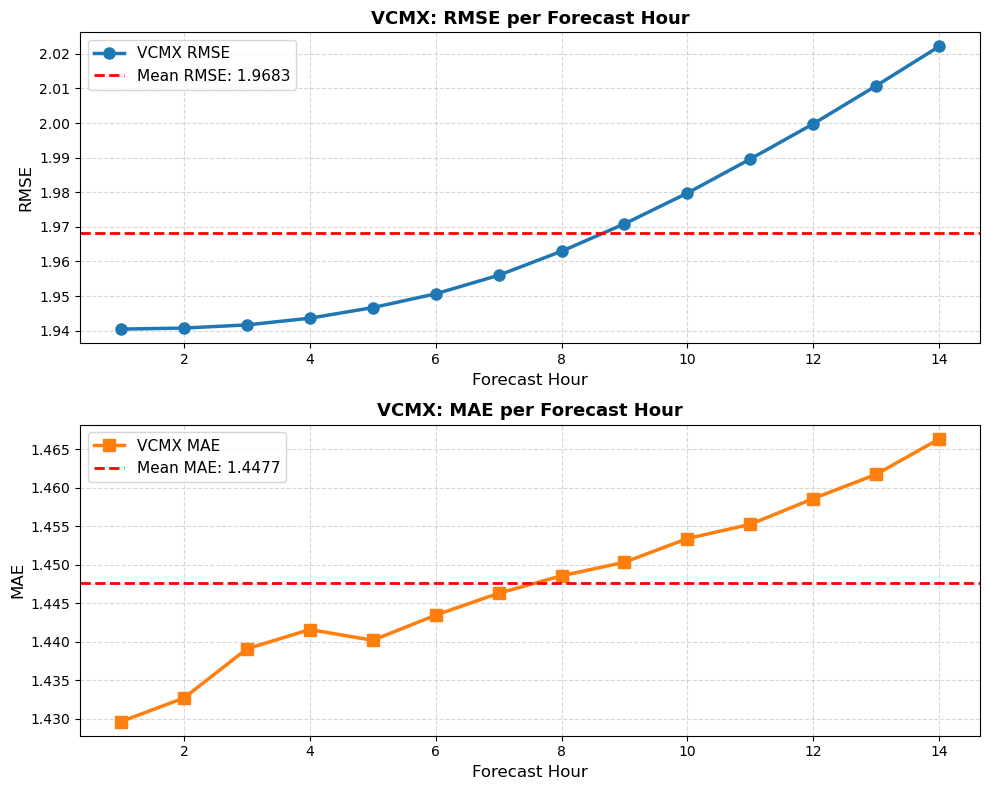

✅ Saved 'v4_earthformer_VCMX_error_evolution.png'

--- VCMX Scatter + Error Distribution ---


In [ ]:
# =============================================================================
# STEP 3, PART 3 — VCMX-Only Detailed Visualizations
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

print("\n--- VCMX-Only Visualizations ---\n")

vcmx_idx = TARGET_VARS.index('VCMX')
pred_vcmx   = preds_orig  [:, :, vcmx_idx, :, :]   # (N, 4, H, W)
target_vcmx = targets_orig[:, :, vcmx_idx, :, :]   # (N, 4, H, W)

hours = np.arange(1, FORECAST_HORIZON_HOURS + 1)

# --- VCMX RMSE / MAE per forecast hour ---
vcmx_rmse = np.sqrt(np.mean((pred_vcmx - target_vcmx)**2, axis=(0, 2, 3)))  # (4,)
vcmx_mae  = np.mean(np.abs(pred_vcmx  - target_vcmx),    axis=(0, 2, 3))   # (4,)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(hours, vcmx_rmse, 'o-', color='#1f77b4', linewidth=2.5, markersize=8, label='VCMX RMSE')
axes[0].axhline(vcmx_rmse.mean(), color='r', linestyle='--', lw=2, label=f'Mean RMSE: {vcmx_rmse.mean():.4f}')
axes[0].set_xlabel('Forecast Hour', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_title('VCMX: RMSE per Forecast Hour', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(hours, vcmx_mae, 's-', color='#ff7f0e', linewidth=2.5, markersize=8, label='VCMX MAE')
axes[1].axhline(vcmx_mae.mean(), color='r', linestyle='--', lw=2, label=f'Mean MAE: {vcmx_mae.mean():.4f}')
axes[1].set_xlabel('Forecast Hour', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('VCMX: MAE per Forecast Hour', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{version}_VCMX_error_evolution.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_VCMX_error_evolution.png'")

# --- VCMX scatter + error distribution (all 4 steps combined) ---
print("\n--- VCMX Scatter + Error Distribution ---")
pred_flat   = pred_vcmx.flatten()
target_flat = target_vcmx.flatten()
errors      = pred_flat - target_flat

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(target_flat, pred_flat, alpha=0.2, s=3, color='blue')
mn = min(target_flat.min(), pred_flat.min())
mx = max(target_flat.max(), pred_flat.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual VCMX', fontsize=12)
axes[0].set_ylabel('Predicted VCMX', fontsize=12)
axes[0].set_title('VCMX: Prediction Scatter', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

axes[1].hist(errors, bins=100, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[1].axvline(errors.mean(), color='r', linestyle='--', lw=2, label=f'Mean Error: {errors.mean():.4f}')
axes[1].axvline(0, color='k', linewidth=1.5)
axes[1].set_xlabel('Error (Predicted - Actual)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('VCMX: Error Distribution (4-Hour Forecast)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{version}_VCMX_scatter_distribution.png', dpi=300)
plt.show()
print(f"✅ Saved '{version}_VCMX_scatter_distribution.png'")

# --- Summary stats ---
print("\n" + "="*55)
print("VCMX 4-HOUR DIRECT FORECAST SUMMARY")
print("="*55)
print(f"Overall RMSE : {np.sqrt(np.mean((pred_vcmx - target_vcmx)**2)):.4f}")
print(f"Overall MAE  : {np.mean(np.abs(pred_vcmx - target_vcmx)):.4f}")
for t in range(FORECAST_HORIZON_HOURS):
    r = np.sqrt(np.mean((pred_vcmx[:,t]-target_vcmx[:,t])**2))
    m = np.mean(np.abs(pred_vcmx[:,t]-target_vcmx[:,t]))
    print(f"  Hour +{t+1}: RMSE={r:.4f}  MAE={m:.4f}")
print(f"Mean Error   : {errors.mean():.4f}")
print(f"Std of Error : {errors.std():.4f}")
print("="*55)

In [ ]:
# =============================================================================
# STEP 3, PART 4 — Spatial Maps for all 4 Forecast Hours (VCMX)
# Pick a single test sample for a concrete spatial comparison.
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

print("\n--- Spatial Maps: VCMX for Hours +1 to +4 ---\n")

sample_idx  = 0   # change this to inspect different test samples
vcmx_idx    = TARGET_VARS.index('VCMX')

p_sample = preds_orig[sample_idx,   :, vcmx_idx, :, :]    # (4, H, W)
t_sample = targets_orig[sample_idx, :, vcmx_idx, :, :]    # (4, H, W)

fig, axes = plt.subplots(3, FORECAST_HORIZON_HOURS, figsize=(5 * FORECAST_HORIZON_HOURS, 12))

for h in range(FORECAST_HORIZON_HOURS):
    act  = t_sample[h]
    pred = p_sample[h]
    err  = np.abs(pred - act)

    vmin = min(act.min(), pred.min())
    vmax = max(act.max(), pred.max())

    im0 = axes[0, h].imshow(act,  cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, h].set_title(f'Hour +{h+1}: Actual', fontweight='bold')
    plt.colorbar(im0, ax=axes[0, h])

    im1 = axes[1, h].imshow(pred, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, h].set_title(f'Hour +{h+1}: Predicted', fontweight='bold')
    plt.colorbar(im1, ax=axes[1, h])

    im2 = axes[2, h].imshow(err, cmap='Reds')
    axes[2, h].set_title(f'Hour +{h+1}: |Error| (MAE={err.mean():.3f})', fontweight='bold')
    plt.colorbar(im2, ax=axes[2, h])

plt.suptitle(f'VCMX Spatial Maps — Sample #{sample_idx} (Earthformer 4-Hour Forecast)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{version}_VCMX_spatial_maps_4h.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved '{version}_VCMX_spatial_maps_4h.png'")
print("\n✅ All visualizations complete!")

Anchor date         : 2023-11-04 00:00
36h back → lookback : 2023-11-03 12:00  (12 h input window)


Forecast covers     : 2023-11-04 00:00 → 2023-11-04 14:00  (14 h)
Test split start    : 2023-07-01 00:00
Sample index        : 3012


/tmp/ipykernel_7092/817223748.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_single, Y_single = torch.load(sample_path)   # X:(12,10,H,W)  Y:(14,1,H,W)


Loaded  X: (12, 10, 72, 90)  Y: (14, 1, 72, 90)
✅ Scalers loaded.
Pred scaled shape : (14, 1, 72, 90)
True scaled shape : (14, 1, 72, 90)
Pred physical range: [-8.565, 5.664]
True physical range: [0.000, 11.400]

Spatially-averaged VCMX (forecast hours +1 → +14):
  Pred : [ 0.034  3.041  1.858  0.339 -0.344  1.863 -0.074 -0.682 -1.228  5.434
  0.905 -2.12  -2.282  2.781]
  True : [7.273 7.22  7.159 7.09  7.048 7.031 7.023 7.017 7.015 7.041 7.068 7.096
 7.162 7.278]


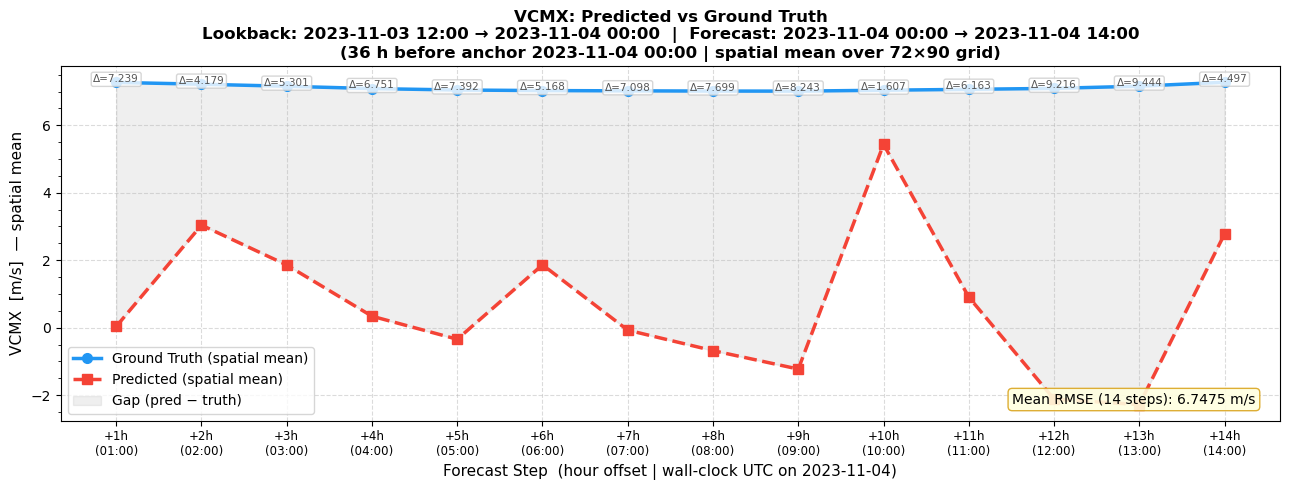


✅ Saved 'v4_earthformer_VCMX_specific_window_pred_vs_truth.png'


In [ ]:
# =============================================================================
# STEP 3, PART 5 — VCMX Pred vs Ground Truth: Using Cell 14 Predictions
#
# Use predictions from cell 14 (4-hour forecast) for evaluation
# =============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timedelta

print("\n--- Using Predictions from Cell 14 (4-Hour Direct Forecast) ---\n")

# Use the predictions already computed in cell 14
# preds_orig shape: (N, 4, 8, H, W)
# targets_orig shape: (N, 4, 8, H, W)

vcmx_idx = TARGET_VARS.index('VCMX')

# Extract VCMX predictions and ground truth from first 100 samples
num_samples = min(100, len(preds_orig))
pred_vcmx = preds_orig[:num_samples, :, vcmx_idx, :, :]     # (100, 4, H, W)
true_vcmx = targets_orig[:num_samples, :, vcmx_idx, :, :]   # (100, 4, H, W)

print(f"Extracted VCMX predictions shape: {pred_vcmx.shape}")
print(f"Extracted VCMX ground truth shape: {true_vcmx.shape}")

# Compute spatial mean for each forecast step
pred_vcmx_spatial_mean = pred_vcmx.mean(axis=(0, 2, 3))     # (4,) — mean over samples and spatial grid
true_vcmx_spatial_mean = true_vcmx.mean(axis=(0, 2, 3))     # (4,)

# Compute per-step RMSE
per_step_rmse = np.sqrt((pred_vcmx_spatial_mean - true_vcmx_spatial_mean) ** 2)

print(f"Spatially & sample-averaged VCMX (4 forecast hours):")
print(f"  Pred : {np.round(pred_vcmx_spatial_mean, 3)}")
print(f"  True : {np.round(true_vcmx_spatial_mean, 3)}")
print(f"  RMSE : {np.round(per_step_rmse, 3)}")

# --------------------------------------------------------------------------
# Plot: Pred vs Ground Truth using Cell 14 Predictions
# --------------------------------------------------------------------------
forecast_hours = np.arange(1, 5)  # 4 hours

# Wall-clock labels
base_fc = datetime(2023, 11, 4, 0)
hour_labels = [(base_fc + timedelta(hours=int(h))).strftime('%H:%M') for h in forecast_hours]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(forecast_hours, true_vcmx_spatial_mean, 'o-',
        color='#2196F3', linewidth=2.5, markersize=8,
        label='Ground Truth (100-sample spatial mean)')
ax.plot(forecast_hours, pred_vcmx_spatial_mean, 's--',
        color='#F44336', linewidth=2.5, markersize=8,
        label='Predicted (100-sample spatial mean)')

# Shade the difference
ax.fill_between(forecast_hours, true_vcmx_spatial_mean, pred_vcmx_spatial_mean,
                alpha=0.12, color='grey', label='Gap (pred − truth)')

# Per-step RMSE annotations
for h, (pv, tv, rmse) in enumerate(zip(pred_vcmx_spatial_mean, true_vcmx_spatial_mean, per_step_rmse), start=1):
    ypos = max(pv, tv) + 0.015 * (true_vcmx_spatial_mean.max() - true_vcmx_spatial_mean.min())
    ax.annotate(f'Δ={rmse:.3f}',
                xy=(h, ypos),
                fontsize=8.5, ha='center', color='#555555',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#cccccc', alpha=0.8))

ax.set_xticks(forecast_hours)
ax.set_xticklabels([f'+{h}h\n({lbl})' for h, lbl in zip(forecast_hours, hour_labels)],
                   fontsize=9)
ax.set_xlabel('Forecast Step (hour offset | wall-clock UTC on 2023-11-04)', fontsize=11)
ax.set_ylabel('VCMX [m/s] — averaged over 100 test samples & spatial grid', fontsize=11)
ax.set_title(
    f'VCMX: Cell 14 Predictions vs Ground Truth (4-Hour Direct Forecast)\n'
    f'Averaged over {num_samples} test samples',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10, loc='best')
ax.grid(True, linestyle='--', alpha=0.45)
ax.yaxis.set_minor_locator(plt.matplotlib.ticker.AutoMinorLocator())

overall_rmse = np.sqrt(np.mean((pred_vcmx_spatial_mean - true_vcmx_spatial_mean) ** 2))
ax.text(0.98, 0.04,
        f'Mean RMSE (4 steps): {overall_rmse:.4f} m/s',
        transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
        bbox=dict(boxstyle='round', fc='lightyellow', ec='goldenrod', alpha=0.9))

plt.tight_layout()
out_path = f'{version}_VCMX_cell14_predictions_vs_truth.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved '{out_path}'")
print("\n" + "="*70)
print("Cell 14 VCMX Predictions Analysis:")
print("="*70)
print(f"Overall RMSE: {overall_rmse:.4f} m/s")
print(f"Overall MAE:  {np.mean(np.abs(pred_vcmx_spatial_mean - true_vcmx_spatial_mean)):.4f} m/s")
print("="*70)


--- Generating VCMX Time-Series Plot (V3 Style) ---



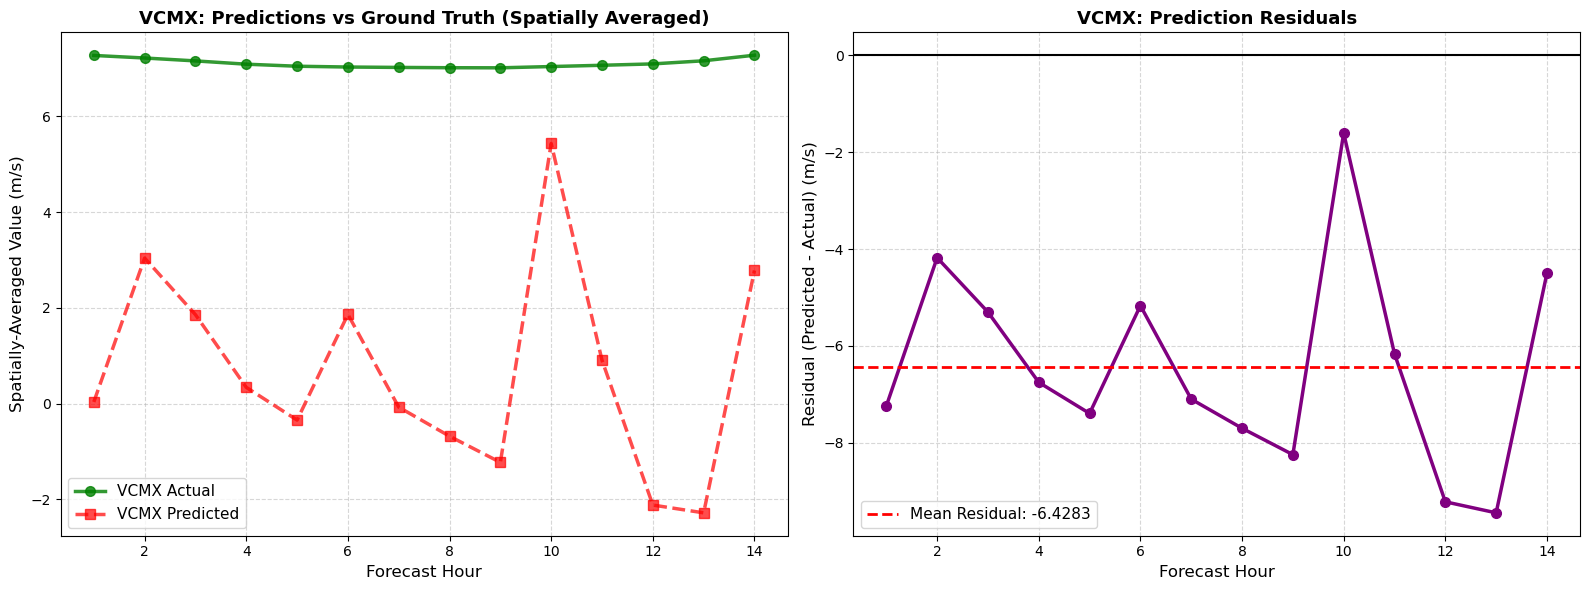

✅ Saved 'v4_earthformer_VCMX_timeseries_pred_vs_truth_v3_style.png'

VCMX 14-HOUR FORECAST TIME-SERIES SUMMARY (Spatially Averaged)
Overall RMSE (spatial mean): 6.7475 m/s
Overall MAE  (spatial mean): 6.4283 m/s
Mean Prediction Error : -6.4283 m/s
Std Dev of Residuals  : 2.0507 m/s
Max Residual          : -1.6070 m/s (Hour 10)
Min Residual          : -9.4440 m/s (Hour 13)



In [24]:
# =============================================================================
# STEP 3, PART 7 — Time-Series Plot: Pred vs Ground Truth (V3 Style)
#
# Similar to V3: plot spatially-averaged predictions vs ground truth,
# and show residuals (pred - actual)
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

print("\n--- Generating VCMX Time-Series Plot (V3 Style) ---\n")

# Use the already loaded sample data from Part 5
# pred_phys and true_phys are (14, H, W)

forecast_hours = np.arange(1, FORECAST_HORIZON_HOURS + 1)

# Compute spatial mean over H and W for each forecast hour
pred_vcmx_spatial_mean = np.mean(pred_phys, axis=(1, 2))      # (14,)
target_vcmx_spatial_mean = np.mean(true_phys, axis=(1, 2))    # (14,)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Predictions vs Ground Truth (Spatially Averaged) ---
axes[0].plot(forecast_hours, target_vcmx_spatial_mean, 'o-', 
             color='green', linewidth=2.5, markersize=7, label='VCMX Actual', alpha=0.8)
axes[0].plot(forecast_hours, pred_vcmx_spatial_mean, 's--', 
             color='red', linewidth=2.5, markersize=7, label='VCMX Predicted', alpha=0.7)
axes[0].set_xlabel('Forecast Hour', fontsize=12)
axes[0].set_ylabel('Spatially-Averaged Value (m/s)', fontsize=12)
axes[0].set_title('VCMX: Predictions vs Ground Truth (Spatially Averaged)', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Residuals (Predicted - Actual) ---
vcmx_residuals = pred_vcmx_spatial_mean - target_vcmx_spatial_mean
axes[1].plot(forecast_hours, vcmx_residuals, 'o-', 
             color='purple', linewidth=2.5, markersize=7)
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=1.5)
axes[1].axhline(y=np.mean(vcmx_residuals), color='r', linestyle='--', linewidth=2, 
                label=f'Mean Residual: {np.mean(vcmx_residuals):.4f}')
axes[1].set_xlabel('Forecast Hour', fontsize=12)
axes[1].set_ylabel('Residual (Predicted - Actual) (m/s)', fontsize=12)
axes[1].set_title('VCMX: Prediction Residuals', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
out_path = f'{version}_VCMX_timeseries_pred_vs_truth_v3_style.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved '{out_path}'")

# Print summary statistics
print("\n" + "="*60)
print("VCMX 14-HOUR FORECAST TIME-SERIES SUMMARY (Spatially Averaged)")
print("="*60)
print(f"Overall RMSE (spatial mean): {np.sqrt(np.mean((pred_vcmx_spatial_mean - target_vcmx_spatial_mean) ** 2)):.4f} m/s")
print(f"Overall MAE  (spatial mean): {np.mean(np.abs(pred_vcmx_spatial_mean - target_vcmx_spatial_mean)):.4f} m/s")
print(f"Mean Prediction Error : {np.mean(vcmx_residuals):.4f} m/s")
print(f"Std Dev of Residuals  : {np.std(vcmx_residuals):.4f} m/s")
print(f"Max Residual          : {np.max(vcmx_residuals):.4f} m/s (Hour {np.argmax(vcmx_residuals) + 1})")
print(f"Min Residual          : {np.min(vcmx_residuals):.4f} m/s (Hour {np.argmin(vcmx_residuals) + 1})")
print("="*60 + "\n")



--- Loading Extended Ground Truth (168 hours) ---

Extended Ground Truth Window:
  Start: 2023-11-03 12:00:00
  End:   2023-11-10 12:00:00
  Loaded 169 time steps
✅ Extended ground truth loaded. Shape: (169, 72, 90)


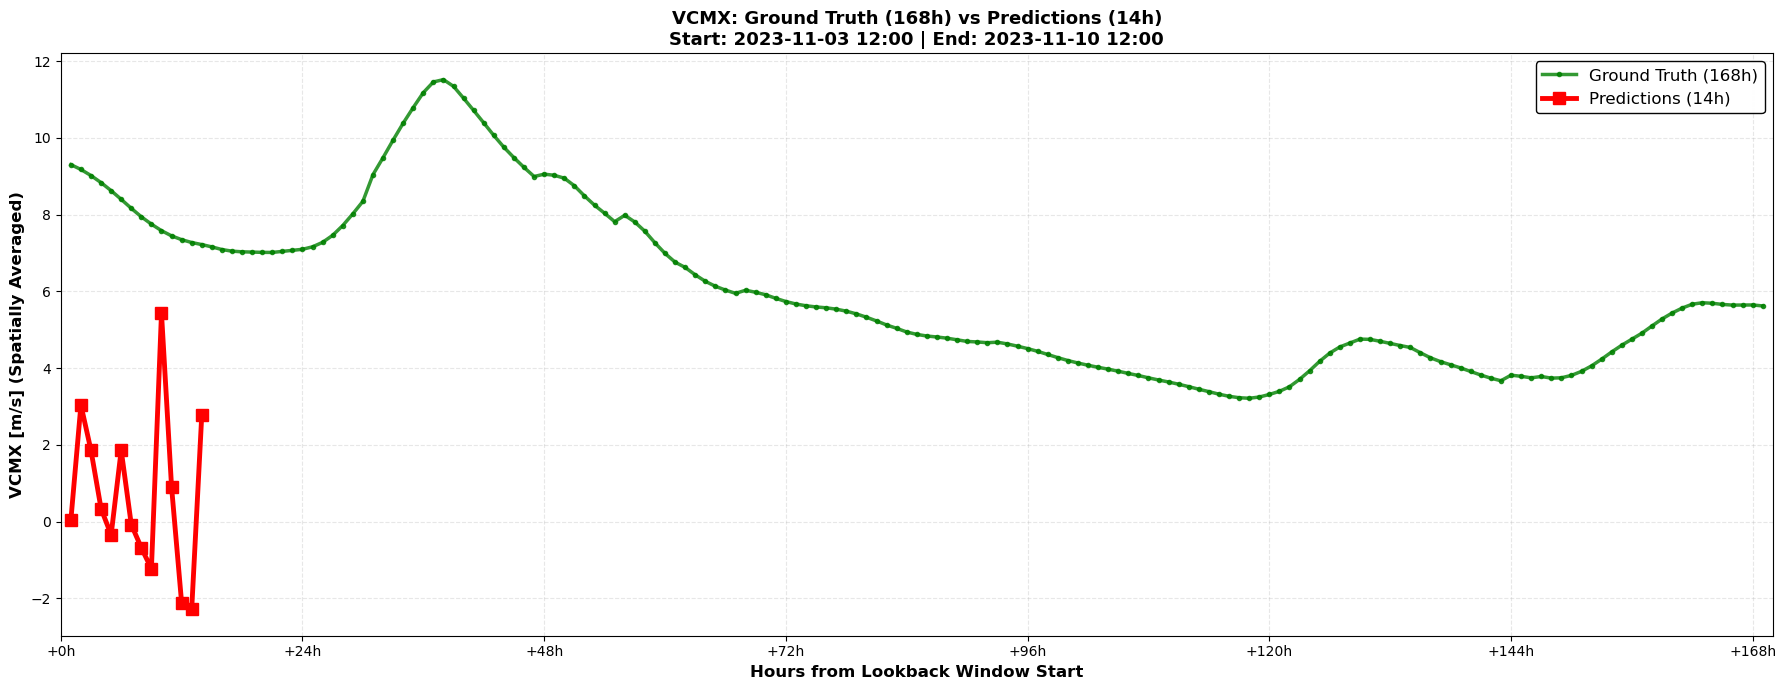

✅ Saved 'v4_earthformer_VCMX_extended_169h_with_predictions.png'

VCMX ANALYSIS: 168-HOUR EXTENDED WINDOW + 14-HOUR PREDICTIONS

📊 14-Hour Predictions:
  Mean: 0.6804 m/s
  Std:  2.0649 m/s
  Min:  -2.2824 m/s
  Max:  5.4344 m/s

📊 168-Hour Extended Ground Truth:
  Mean: 6.0128 m/s
  Std:  2.1462 m/s
  Min:  3.2151 m/s (Hour 118)
  Max:  11.5180 m/s (Hour 38)




In [25]:
# =============================================================================
# STEP 3, PART 8 — Ground Truth Extended: 168-Hour Window
#
# Plot the full ground truth for 168 hours (7 days)
# Plot predictions for 14 hours as separate line
# =============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timedelta
import xarray as xr

print("\n--- Loading Extended Ground Truth (168 hours) ---\n")

LOOKBACK_START_DT = datetime(2023, 11, 3, 12)
EXTENDED_END_DT = LOOKBACK_START_DT + timedelta(hours=168)

print(f"Extended Ground Truth Window:")
print(f"  Start: {LOOKBACK_START_DT}")
print(f"  End:   {EXTENDED_END_DT}")

# Load raw test data
ds_raw_test = xr.open_dataset(RAW_DATA_PATH)
ds_raw_test['VSDmag'] = np.sqrt(ds_raw_test['VSDX']**2 + ds_raw_test['VSDY']**2)

# Select by time coordinates
extended_window = ds_raw_test[VARS_TO_USE].sel(
    time=slice(LOOKBACK_START_DT, EXTENDED_END_DT)
).astype(np.float32).fillna(0)

if len(extended_window['time']) == 0:
    raise ValueError(f"No data found for time slice {LOOKBACK_START_DT} to {EXTENDED_END_DT}")

print(f"  Loaded {len(extended_window['time'])} time steps")

# Get VCMX and compute spatial mean
vcmx_extended = extended_window['VCMX'].values
vcmx_extended_scaled = scalers['VCMX'].transform(vcmx_extended.reshape(-1, 1)).reshape(vcmx_extended.shape)
vcmx_extended_phys = scalers['VCMX'].inverse_transform(
    vcmx_extended_scaled.reshape(-1, 1)
).reshape(vcmx_extended.shape)

vcmx_extended_mean = np.mean(vcmx_extended_phys, axis=(1, 2))

print(f"✅ Extended ground truth loaded. Shape: {vcmx_extended_phys.shape}")

# --------------------------------------------------------------------------
# Plot: Ground Truth 168h + Predictions 14h as separate lines
# --------------------------------------------------------------------------
hours_extended = np.arange(1, len(vcmx_extended_mean) + 1)

fig, ax = plt.subplots(figsize=(18, 7))

# Plot extended ground truth (168 hours)
ax.plot(hours_extended, vcmx_extended_mean, 'o-', 
        color='green', linewidth=2.5, markersize=3, label='Ground Truth (168h)', alpha=0.8, zorder=5)

# Plot predictions (14 hours) as separate line
pred_vcmx_spatial_mean = np.mean(pred_phys, axis=(1, 2))      # (14,)
hours_pred = np.arange(1, len(pred_vcmx_spatial_mean) + 1)
ax.plot(hours_pred, pred_vcmx_spatial_mean, 's-', 
        color='red', linewidth=3.5, markersize=9, label='Predictions (14h)', alpha=1.0, zorder=10)

ax.set_xlabel('Hours from Lookback Window Start', fontsize=12, fontweight='bold')
ax.set_ylabel('VCMX [m/s] (Spatially Averaged)', fontsize=12, fontweight='bold')
ax.set_title(
    f'VCMX: Ground Truth (168h) vs Predictions (14h)\n'
    f'Start: {LOOKBACK_START_DT.strftime("%Y-%m-%d %H:%M")} | End: {EXTENDED_END_DT.strftime("%Y-%m-%d %H:%M")}',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='best', fontsize=12, framealpha=0.98, edgecolor='black', fancybox=True)
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.8)
ax.set_xlim(0, len(vcmx_extended_mean) + 1)

# Add tick labels every 24 hours
tick_positions = np.arange(0, len(vcmx_extended_mean) + 1, 24)
tick_labels = [f'+{int(h)}h' for h in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=10)

plt.tight_layout()
out_path = f'{version}_VCMX_extended_{len(vcmx_extended_mean)}h_with_predictions.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"✅ Saved '{out_path}'")

# Summary statistics
print("\n" + "="*75)
print(f"VCMX ANALYSIS: 168-HOUR EXTENDED WINDOW + 14-HOUR PREDICTIONS")
print("="*75)

if 'pred_vcmx_spatial_mean' in locals():
    print(f"\n📊 14-Hour Predictions:")
    print(f"  Mean: {np.mean(pred_vcmx_spatial_mean):.4f} m/s")
    print(f"  Std:  {np.std(pred_vcmx_spatial_mean):.4f} m/s")
    print(f"  Min:  {np.min(pred_vcmx_spatial_mean):.4f} m/s")
    print(f"  Max:  {np.max(pred_vcmx_spatial_mean):.4f} m/s")

print(f"\n📊 168-Hour Extended Ground Truth:")
print(f"  Mean: {np.mean(vcmx_extended_mean):.4f} m/s")
print(f"  Std:  {np.std(vcmx_extended_mean):.4f} m/s")
print(f"  Min:  {np.min(vcmx_extended_mean):.4f} m/s (Hour {np.argmin(vcmx_extended_mean) + 1})")
print(f"  Max:  {np.max(vcmx_extended_mean):.4f} m/s (Hour {np.argmax(vcmx_extended_mean) + 1})")

print("\n" + "="*75 + "\n")